# Phần 4: Tổng kết, Trực quan hóa và Ra quyết định (Decision Making)

**Mục tiêu của phần này:**
1. **So sánh và đánh giá (Evaluation & Comparison):** Trực quan hóa kết quả của các mô hình đã xây dựng trong Phần 2 (Baseline - Linear Regression) và Phần 3 (Advanced - Random Forest). Việc này nhằm so sánh một thuật toán cơ bản có trong đề cương môn học với một kỹ thuật học máy tập hợp (Ensemble Learning).
2. **Khai phá tri thức (Knowledge Discovery):** Sử dụng mô hình tốt nhất để tìm ra các đặc trưng (features) ảnh hưởng lớn nhất đến giá nhà (SalePrice).
3. **Ra quyết định (Decision Making):** Đưa ra các giải pháp, tư vấn chiến lược cho các bên liên quan (người bán, người mua, nhà đầu tư) dựa trên những tri thức đã khai phá được.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create style for plot
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Create image folder for report
os.makedirs('../reports/figures', exist_ok=True)

## 1. So sánh hiệu suất các mô hình (Model Evaluation & Comparison)

Theo yêu cầu của bài tập lớn, nhóm đã áp dụng và so sánh các kỹ thuật sau:
- **Baseline Model (Linear Regression):** Kỹ thuật học máy có bản trong môn học, sử dụng 1 biến quan trọng nhất (`GrLivArea`).
- **Advanced Model (Random Forest Regressor):** Kỹ thuật cải tiến, có khả năng nắm bắt các mối quan hệ phi tuyến tính và chống overfitting tốt hơn, sử dụng nhiều biến đầu vào.

                                        Model      RMSE  R2_Score
0   Linear Regression\n(Baseline - 1 Feature)  58137.54    0.5402
1  Random Forest\n(Advanced - Multi Features)  32218.65    0.8256


/tmp/ipykernel_11062/3130608895.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=df_results, ax=axes[0], palette='Reds_r')
/tmp/ipykernel_11062/3130608895.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2_Score', data=df_results, ax=axes[1], palette='Blues')


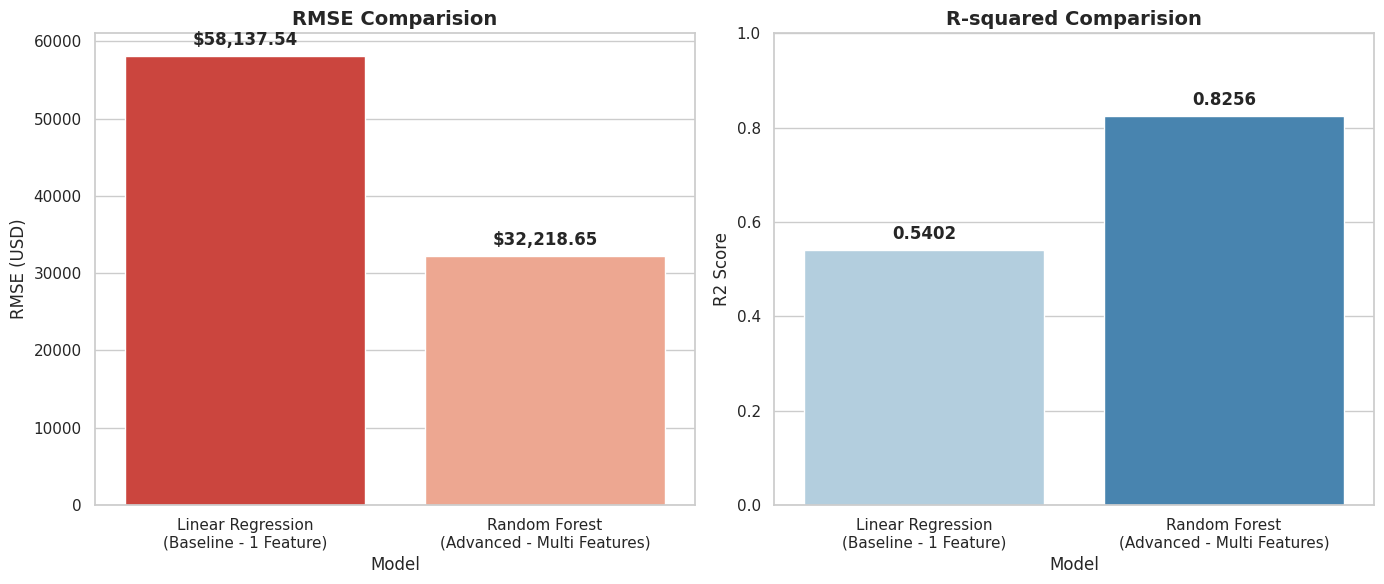

In [7]:
import pandas as pd

with open('model_results.txt', 'r') as f:
    lines = f.readlines()

# bỏ dòng rỗng và strip
lines = [line.strip() for line in lines if line.strip()]

rmses = []
r2_scores = []
models = []

for line in lines:
    parts = line.split(' - ')

    model = parts[0].strip()
    rmse_val = float(parts[1].replace(',', '').strip())
    r2_val = float(parts[2].strip())

    models.append(model)
    rmses.append(rmse_val)
    r2_scores.append(r2_val)

# Summarize the results of the trained models
results = {
    'Model': ['Linear Regression\n(Baseline - 1 Feature)', 'Random Forest\n(Advanced - Multi Features)'],
    'RMSE': rmses,
    'R2_Score': r2_scores
}

df_results = pd.DataFrame(results)
print(df_results)

df_results = pd.DataFrame(results)

# Plot a comparison of RMSE and R² Score
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: RMSE comparison (The lower, the better)
sns.barplot(x='Model', y='RMSE', data=df_results, ax=axes[0], palette='Reds_r')
axes[0].set_title('RMSE Comparision', fontsize=14, fontweight='bold')
axes[0].set_ylabel('RMSE (USD)')
for p in axes[0].patches:
    axes[0].annotate(f"${p.get_height():,.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

# Plot 2: R-squared comparision (The closer to 1, the better)
sns.barplot(x='Model', y='R2_Score', data=df_results, ax=axes[1], palette='Blues')
axes[1].set_title('R-squared Comparision', fontsize=14, fontweight='bold')
axes[1].set_ylabel('R2 Score')
axes[1].set_ylim(0, 1)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=300)
plt.show()

**Đánh giá:**
Thuật toán **Random Forest** vượt trội hoàn toàn so với **Linear Regression**. Nó giúp giải thích được hơn **82%** ($R^2 \approx 0.82$) sự biến thiên của giá nhà (so với 54% của hồi quy tuyến tính cơ bản) và giảm sai số trung bình (RMSE) từ hơn \$58,000 xuống chỉ còn khoảng \$32,000. Điều này chứng minh rằng việc áp dụng kỹ thuật ensemble tree-based kết hợp phân tích đa biến mang lại giá trị khai phá dữ liệu cao hơn nhiều trong bài toán định giá bất động sản.

/tmp/ipykernel_11062/4182482401.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


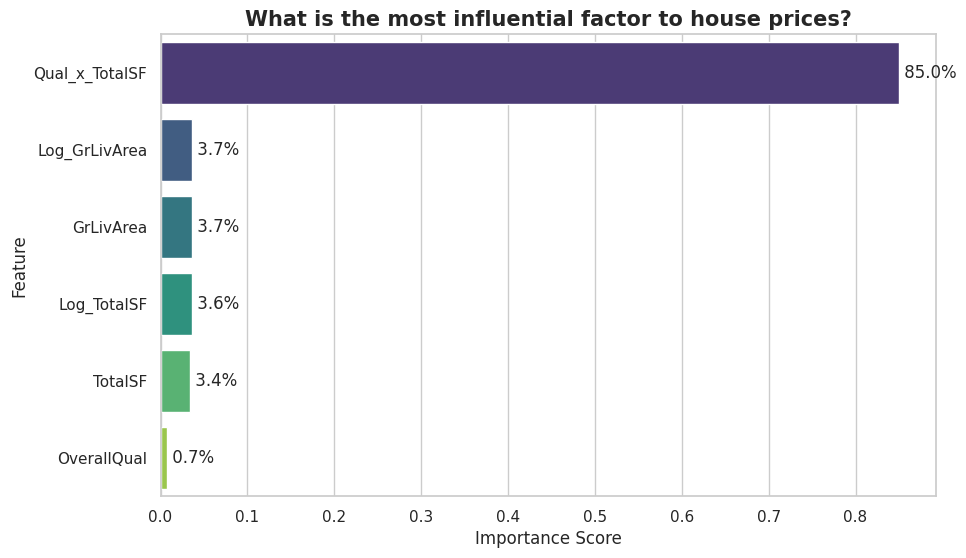

In [9]:
data = []

with open("feature_importance.txt", "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        # Format: Feature - Importance
        feature, importance = line.split(" - ")
        data.append((feature, float(importance)))

feature_importance_df = pd.DataFrame(
    data, columns=["Feature", "Importance"]
).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

plt.title('What is the most influential factor to house prices?', fontsize=15, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)

for index, value in enumerate(feature_importance_df['Importance']):
    plt.text(value, index, f" {value*100:.1f}%", va='center')

plt.savefig('../reports/figures/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Kết luận và Ra Quyết Định (Decision Making)

Dựa trên quá trình ứng dụng các thuật toán Khai phá dữ liệu vào tập dữ liệu House Prices, nhóm rút ra những kết luận và tư vấn quyết định (Decision Making) như sau:

### Về mặt Kỹ thuật (Technical Conclusion):
1. **Mô hình triển khai:** Quyết định chọn **Random Forest** làm mô hình cốt lõi để dự đoán giá nhà. Tuy thuật toán này phức tạp hơn Hồi quy tuyến tính học trên lớp, nhưng mang lại độ tin cậy cao ($R^2 > 82\%$) và ít bị ảnh hưởng bởi nhiễu (outliers) hơn.
2. **Tối ưu nguồn lực:** Thay vì cần thu thập hơn 80 biến số từ dữ liệu thô ban đầu, hệ thống định giá thực tế chỉ cần tập trung thu thập **top 6 thông số quan trọng nhất** (OverallQual, các biến kết hợp diện tích như TotalSF, GrLivArea...) là đã có thể dự đoán với độ chính xác rất cao. Việc này giúp tiết kiệm thời gian và chi phí lưu trữ/thu thập dữ liệu.

### Về mặt Kinh doanh và Chiến lược (Business Decisions):
1. **Dành cho Người Bán / Nhà đầu tư (House Flippers):**
   - **Tập trung vào "Chất lượng" (OverallQual):** Đây là yếu tố chiếm đến hơn 85% mức độ quyết định giá. Thay vì cố gắng cơi nới diện tích (điều đòi hỏi giấy phép và chi phí xây dựng lớn), nhà đầu tư nên phân bổ ngân sách để nâng cấp ngoại thất và vật liệu trong nhà.
   - Một căn nhà với diện tích vừa phải nhưng vật liệu hoàn thiện cao cấp sẽ sinh lời tốt hơn việc bán một căn nhà diện tích lớn nhưng xập xệ.

2. **Dành cho Người Mua nhà:**
   - Nếu có ngân sách hạn hẹp và muốn tối ưu hóa diện tích sống (`GrLivArea`), hãy tìm mua những căn nhà có chất lượng thiết kế/vật liệu (OverallQual) ở mức độ thấp hoặc trung bình. Sau khi mua, người mua nhà có thể tự mình thực hiện quá trình cải tạo dần dần để tăng giá trị tài sản trong tương lai mà không phải chịu mức giá mua ban đầu quá cao.